In [3]:
import requests
import supervision as sv
import torch

from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM

2026-05-06 22:26:34.073875: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [19]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model = AutoModelForCausalLM.from_pretrained("microsoft/Florence-2-base-ft", dtype=torch_dtype, 
                                              trust_remote_code=True, attn_implementation="eager").to(device)
processor = AutoProcessor.from_pretrained("microsoft/Florence-2-base-ft", trust_remote_code=True)

In [26]:
print(f"Total parameters: {model.num_parameters():,}")
print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

Total parameters: 231,414,016
Trainable parameters: 231,414,016


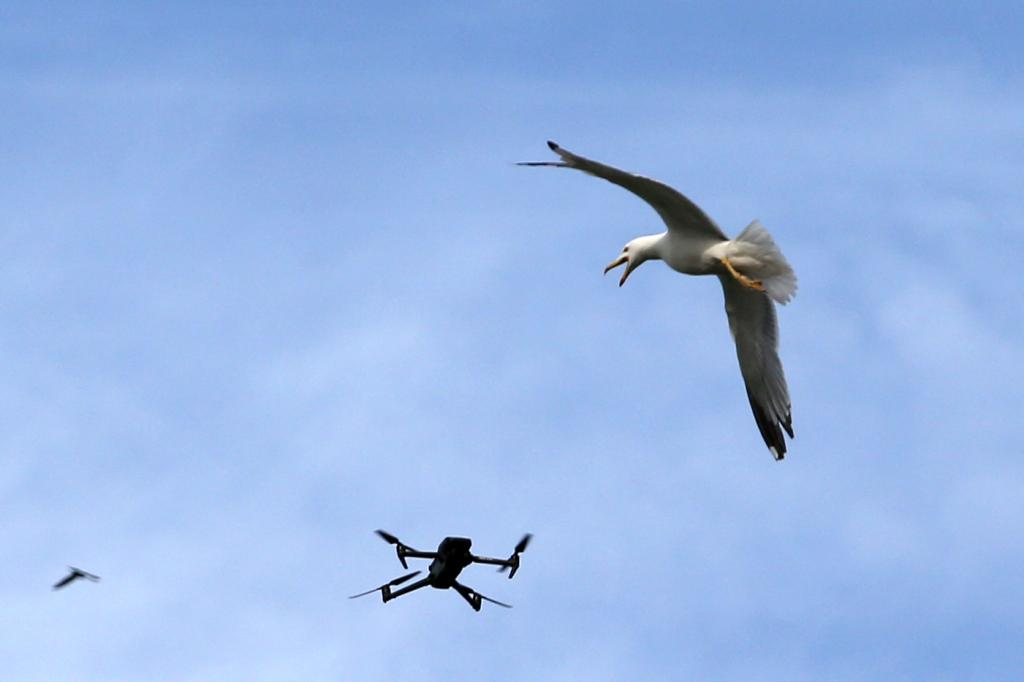

In [70]:
prompt = "<OD>"

#url ="https://videocdn.cdnpk.net/videos/632c467e-ee3b-4ea3-a956-d568d0a14a06/horizontal/thumbnails/large.jpg"
url="https://nypost.com/wp-content/uploads/sites/2/2024/07/gull-chases-drone-skies-ajaccio-85346693.jpg?quality=75&strip=all&w=1024"

image = Image.open(requests.get (url, stream=True). raw)
image

In [72]:
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)

In [74]:
type(inputs)

transformers.feature_extraction_utils.BatchFeature

In [76]:
inputs["pixel_values"].shape

torch.Size([1, 3, 768, 768])

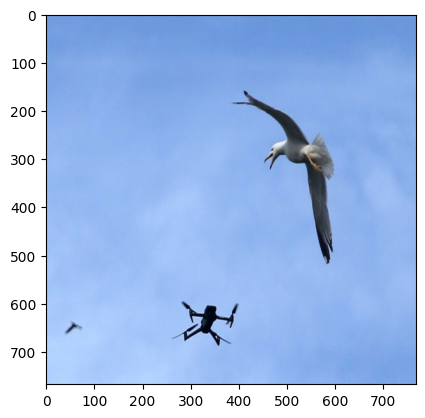

In [78]:
import numpy as np
from matplotlib import pyplot as plt

x = inputs["pixel_values"].cpu().squeeze().numpy()
x = np.moveaxis(x, 0, -1)
x = x - np.min(x)
x = x/np.max(x)
x = x.astype(np.float32)

plt.imshow(x)

In [80]:
inputs["input_ids"]

tensor([[    0,   574, 22486,     5,  8720,    19,  4120,   766,    11,     5,
          2274,     4,     2]])

In [82]:
inputs["pixel_values"]

tensor([[[[-0.0629, -0.0629, -0.0629,  ..., -0.0972, -0.0458, -0.0458],
          [-0.0629, -0.0629, -0.0629,  ..., -0.0972, -0.0629, -0.0458],
          [-0.0629, -0.0629, -0.0629,  ..., -0.0972, -0.0629, -0.0629],
          ...,
          [ 1.1872,  1.2043,  1.2043,  ...,  0.2282,  0.2282,  0.2282],
          [ 1.1529,  1.1872,  1.2214,  ...,  0.2624,  0.2624,  0.2111],
          [ 1.1529,  1.1872,  1.2214,  ...,  0.2624,  0.2624,  0.2111]],

         [[ 0.8004,  0.8004,  0.8004,  ...,  0.7304,  0.7829,  0.7829],
          [ 0.8004,  0.8004,  0.8004,  ...,  0.7304,  0.7654,  0.7829],
          [ 0.8004,  0.8004,  0.8004,  ...,  0.7304,  0.7654,  0.7654],
          ...,
          [ 1.7808,  1.7808,  1.7983,  ...,  0.9755,  0.9755,  0.9755],
          [ 1.7633,  1.7983,  1.8333,  ...,  1.0105,  1.0105,  0.9580],
          [ 1.7633,  1.7983,  1.8333,  ...,  1.0105,  1.0105,  0.9580]],

         [[ 2.0648,  2.0648,  2.0648,  ...,  2.0125,  2.0648,  2.0648],
          [ 2.0648,  2.0648,  

In [84]:
generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024, 
    do_sample=False, 
    num_beams=3, 
    use_cache=False
)

In [85]:
generated_ids

tensor([[    2,     0,  2456, 28885, 50610, 51045, 50790, 51166, 29633,  5103,
         50772, 50474, 51050, 50945, 50321, 51098, 50368, 51135,     2]])

In [86]:
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
generated_text

'</s><s>airplane<loc_341><loc_776><loc_521><loc_897>wild bird<loc_503><loc_205><loc_781><loc_676><loc_52><loc_829><loc_99><loc_866></s>'

In [90]:
parsed_answer = processor.post_process_generation(
    generated_text, 
    task="<OD>", 
    image_size=(image.width, image.height)
)
print (parsed_answer)

{'<OD>': {'bboxes': [[349.6960144042969, 529.572998046875, 534.0160522460938, 612.094970703125], [515.5840454101562, 140.1510009765625, 800.2560424804688, 461.37298583984375], [53.76000213623047, 565.718994140625, 101.88800811767578, 590.9530029296875]], 'labels': ['airplane', 'wild bird', 'wild bird']}}


In [92]:
generated_ids, generated_ids[:, 0:2]

(tensor([[    2,     0,  2456, 28885, 50610, 51045, 50790, 51166, 29633,  5103,
          50772, 50474, 51050, 50945, 50321, 51098, 50368, 51135,     2]]),
 tensor([[2, 0]]))

In [94]:
processor.batch_decode(generated_ids[:, :], skip_special_tokens=False)[0]

'</s><s>airplane<loc_341><loc_776><loc_521><loc_897>wild bird<loc_503><loc_205><loc_781><loc_676><loc_52><loc_829><loc_99><loc_866></s>'

SupervisionWarnings: `Detections.from_lmm` is deprecated since `supervision-0.26.0` and will be removed in `supervision-0.31.0`. Use `Detections.from_vlm` instead.


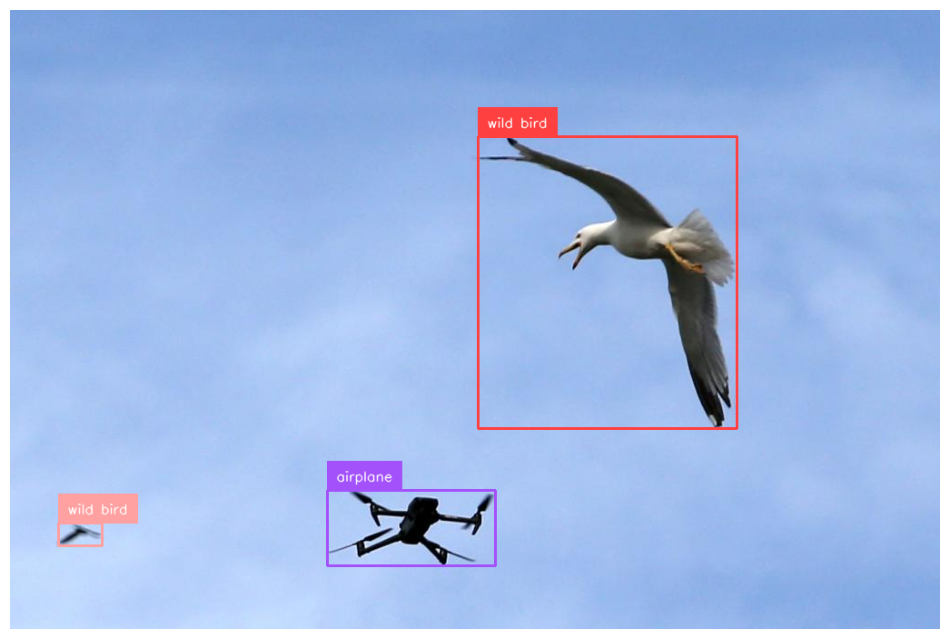

In [96]:
bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup. INDEX)
label_annotator = sv. LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_lmm(sv. LMM. FLORENCE_2, parsed_answer, resolution_wh=image.size)
annotated = bounding_box_annotator.annotate(image, detections=detections)
annotated = label_annotator.annotate(annotated, detections=detections)
sv.plot_image(annotated)

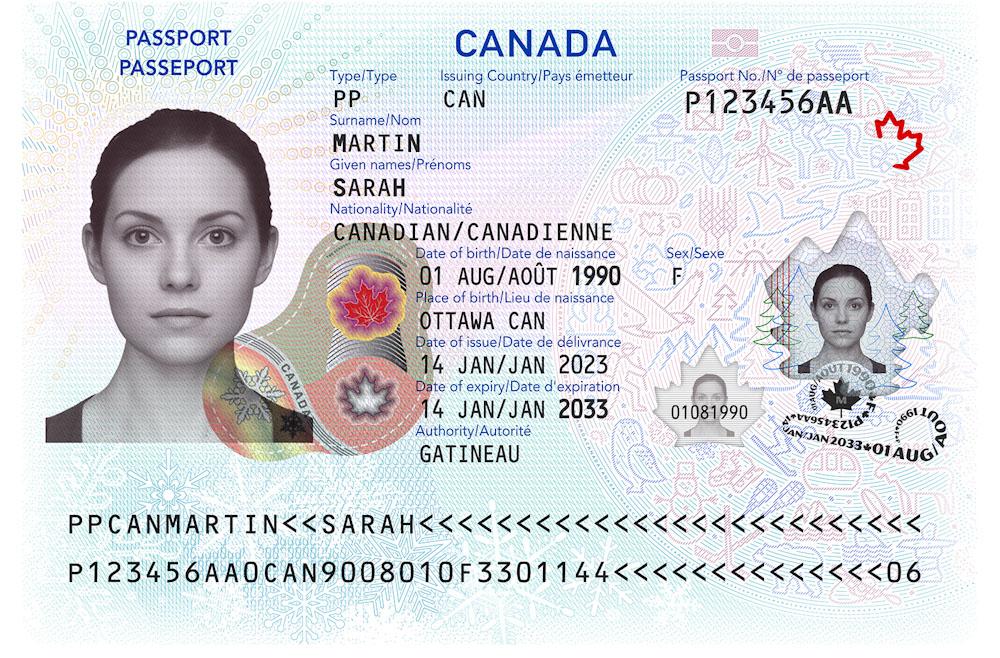

In [118]:
prompt = "<OCR_WITH_REGION>"
url = "https://www.canada.ca/content/dam/ircc/images/services/canadian-passports/passport-data-page-large.jpg"
image = Image.open(requests.get(url, stream=True).raw)
image

In [122]:
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)

In [124]:
generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024, 
    do_sample=False, 
    num_beams=1, 
    use_cache=False
)


In [125]:
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

In [126]:
parsed_answer = processor.post_process_generation(
    generated_text, 
    task="<OCR_WITH_REGION>", 
    image_size=(image.width, image.height)
)
print(parsed_answer)

{'<OCR_WITH_REGION>': {'quad_boxes': [[123.5, 27.30699920654297, 233.5, 27.30699920654297, 233.5, 47.70499801635742, 123.5, 47.70499801635742], [453.5, 27.30699920654297, 617.5, 27.30699920654297, 617.5, 58.89099884033203, 453.5, 58.89099884033203], [118.5, 56.91699981689453, 239.5, 56.91699981689453, 239.5, 77.31500244140625, 118.5, 77.31500244140625], [329.5, 68.76100158691406, 398.5, 68.76100158691406, 398.5, 84.5530014038086, 329.5, 84.5530014038086], [438.5, 66.78700256347656, 634.5, 66.78700256347656, 634.5, 84.5530014038086, 438.5, 84.5530014038086], [332.5, 87.84300231933594, 361.5, 87.84300231933594, 361.5, 107.58300018310547, 332.5, 107.58300018310547], [442.5, 87.84300231933594, 486.5, 87.84300231933594, 486.5, 107.58300018310547, 442.5, 107.58300018310547], [680.5, 66.78700256347656, 872.5, 66.78700256347656, 872.5, 84.5530014038086, 680.5, 84.5530014038086], [684.5, 85.8689956665039, 853.5, 85.8689956665039, 853.5, 115.47899627685547, 684.5, 115.47899627685547], [329.5, 11

SupervisionWarnings: `Detections.from_lmm` is deprecated since `supervision-0.26.0` and will be removed in `supervision-0.31.0`. Use `Detections.from_vlm` instead.


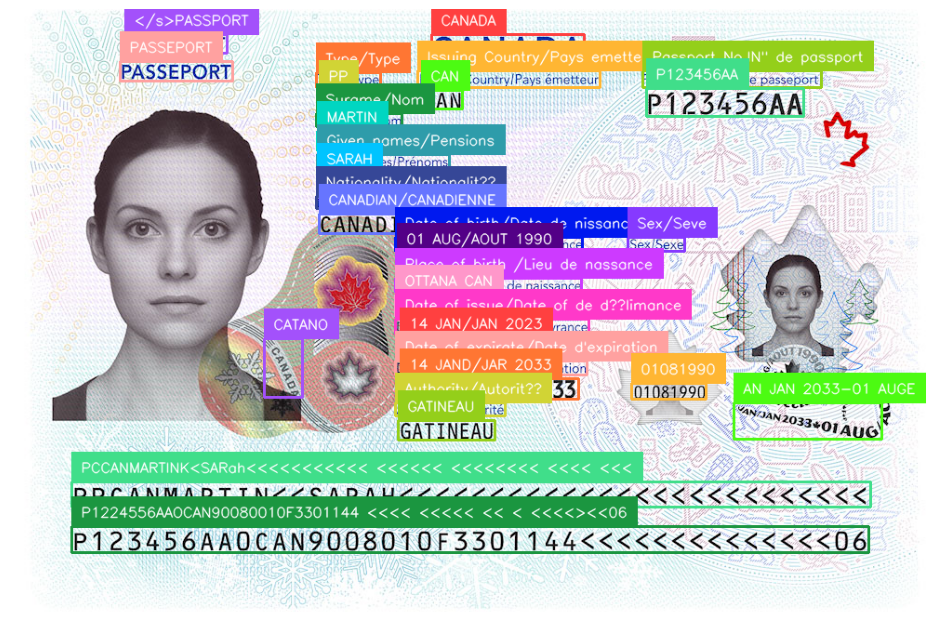

In [130]:
bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup. INDEX)
label_annotator = sv. LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, parsed_answer, resolution_wh=image.size)
annotated = bounding_box_annotator.annotate(image, detections=detections)
annotated = label_annotator.annotate(annotated, detections=detections)
sv.plot_image(annotated)

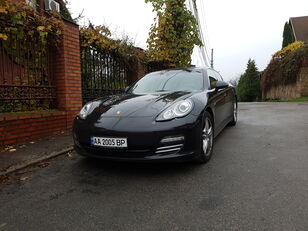

In [148]:
prompt = "<OCR_WITH_REGION>"
url ="https://img.linemedia.com/img/s/sedan-Porsche-Panamera---1736784405119991908_common--25011317502940131400.jpg"
image = Image.open(requests.get(url, stream=True). raw)
image

In [150]:
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)

generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024, 
    do_sample=False, 
    num_beams=3, 
    use_cache=False
)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
parsed_answer = processor.post_process_generation(
    generated_text, 
    task="<OCR_WITH_REGION>", 
    image_size=(image.width, image.height)
)
print(parsed_answer)

{'<OCR_WITH_REGION>': {'quad_boxes': [[91.3219985961914, 136.8675079345703, 126.43399810791016, 138.25350952148438, 125.81800079345703, 146.5695037841797, 90.70600128173828, 144.72149658203125]], 'labels': ['</s>AA 2005 BP']}}


In [152]:
generated_ids.shape

torch.Size([1, 15])

SupervisionWarnings: `Detections.from_lmm` is deprecated since `supervision-0.26.0` and will be removed in `supervision-0.31.0`. Use `Detections.from_vlm` instead.


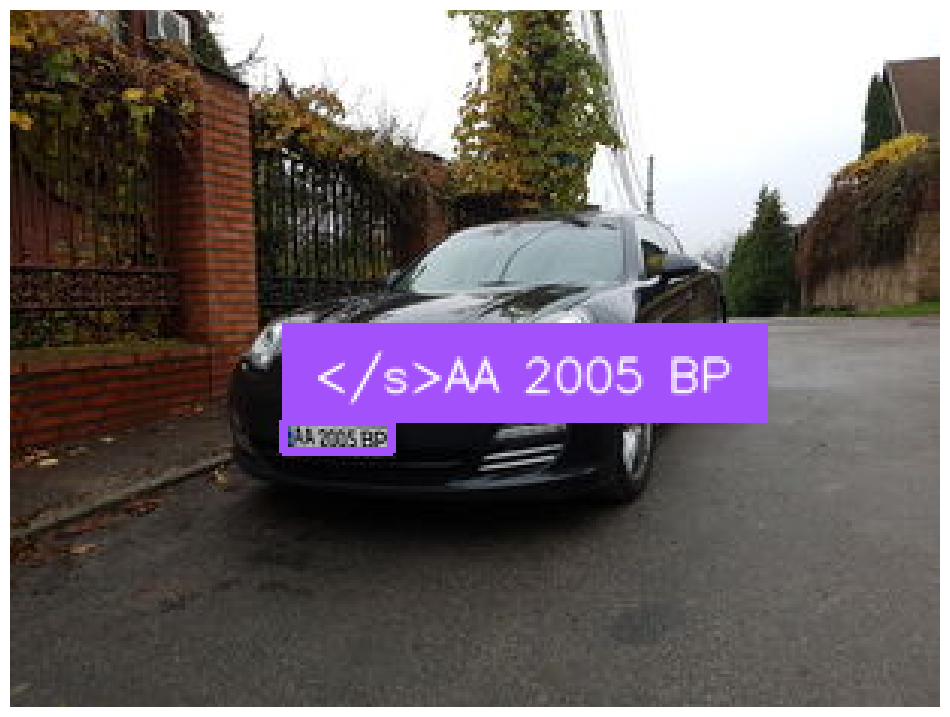

In [154]:
bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup. INDEX)
label_annotator = sv. LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, parsed_answer, resolution_wh=image.size)
annotated = bounding_box_annotator.annotate(image, detections=detections)
annotated = label_annotator.annotate(annotated, detections=detections)
sv.plot_image(annotated)

SupervisionWarnings: `Detections.from_lmm` is deprecated since `supervision-0.26.0` and will be removed in `supervision-0.31.0`. Use `Detections.from_vlm` instead.


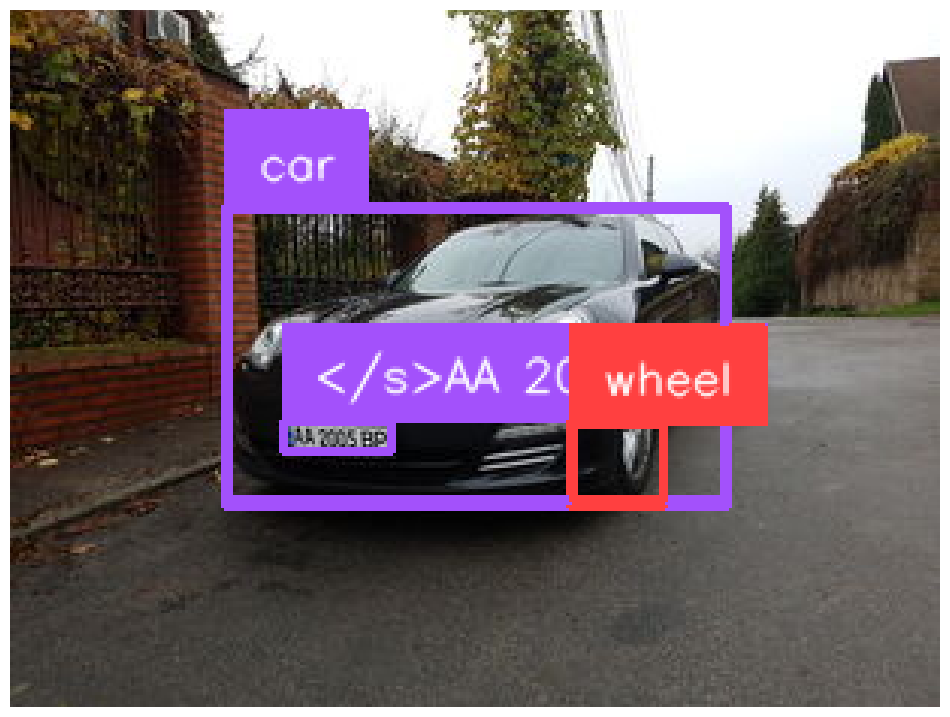

In [168]:
prompt = "<OD>"

inputs = processor(text=prompt, images=image, return_tensors="pt"). to(device, torch_dtype)

generated_ids = model. generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs ["pixel_values"],
    max_new_tokens=1024, 
    do_sample=False, 
    num_beams=3, 
    use_cache=False
)

generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

parsed_answer = processor.post_process_generation(generated_text, task="<OD>", image_size=(image.width, image.height))

bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup. INDEX)

detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, parsed_answer, resolution_wh=image.size)
annotated = bounding_box_annotator.annotate(image, detections=detections)
annotated = label_annotator. annotate(annotated, detections=detections)
sv.plot_image(annotated)

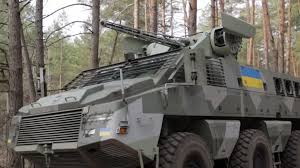

In [180]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR0ggYpzK8cdvHYtTcCGdW_6luImZnBAbaVGA&s"
image = Image.open(requests.get (url, stream=True).raw)
image

In [218]:
for prompt in ["<CAPTION>", "<DETAILED_CAPTION>", "<MORE_DETAILED_CAPTION>"]:
    input = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024, 
        do_sample=False, 
        num_beams=3, 
        use_cache=False
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=prompt, 
        image_size=(image.width, image.height)
    )
    print (parsed_answer)

{'<CAPTION>': 'A military vehicle<loc_20><loc_71><loc_998><loc_998>a machine gun<loc_330><loc_105><loc_620><loc_303>Ukrainian flag<loc_795><loc_382><loc_891><loc_558>'}
{'<DETAILED_CAPTION>': 'A military vehicle<loc_20><loc_71><loc_998><loc_998>a machine gun<loc_330><loc_105><loc_620><loc_303>Ukrainian flag<loc_795><loc_382><loc_891><loc_558>'}
{'<MORE_DETAILED_CAPTION>': 'A military vehicle<loc_20><loc_71><loc_998><loc_998>a machine gun<loc_330><loc_105><loc_620><loc_303>Ukrainian flag<loc_795><loc_382><loc_891><loc_558>'}


{'<OD>': {'bboxes': [[6.750000476837158, 12.01200008392334, 299.5500183105469, 167.7480010986328], [156.15000915527344, 131.79600524902344, 214.65000915527344, 167.7480010986328], [226.35000610351562, 128.60400390625, 274.0500183105469, 167.7480010986328], [279.45001220703125, 129.947998046875, 299.5500183105469, 167.7480010986328]], 'labels': ['machinery vehicle', 'wheel', 'wheel', 'wheel']}}


SupervisionWarnings: `Detections.from_lmm` is deprecated since `supervision-0.26.0` and will be removed in `supervision-0.31.0`. Use `Detections.from_vlm` instead.


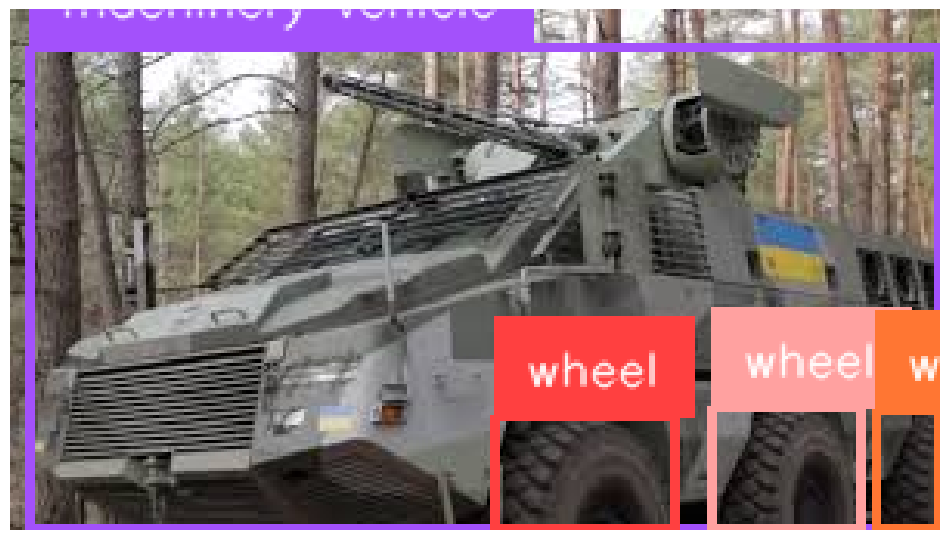

In [220]:
prompt = "<OD>"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(text=prompt, images=image, return_tensors="pt"). to(device, torch_dtype)

generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024, 
    do_sample=False, 
    num_beams=3, 
    use_cache=False
)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
parsed_answer = processor.post_process_generation(
    generated_text, task="<OD>", image_size=(image.width, image.height)
)
print(parsed_answer)

bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, parsed_answer, resolution_wh=image.size)
annotated = bounding_box_annotator.annotate(image, detections=detections)
annotated = label_annotator.annotate(annotated, detections=detections)
sv.plot_image(annotated)

{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[6.150000095367432, 12.01200008392334, 299.5500183105469, 167.7480010986328], [99.1500015258789, 17.7239990234375, 186.15000915527344, 50.987998962402344], [238.65000915527344, 64.26000213623047, 267.45001220703125, 93.82799530029297]], 'labels': ['A military vehicle', 'a machine gun', 'Ukrainian flag']}}


SupervisionWarnings: `Detections.from_lmm` is deprecated since `supervision-0.26.0` and will be removed in `supervision-0.31.0`. Use `Detections.from_vlm` instead.


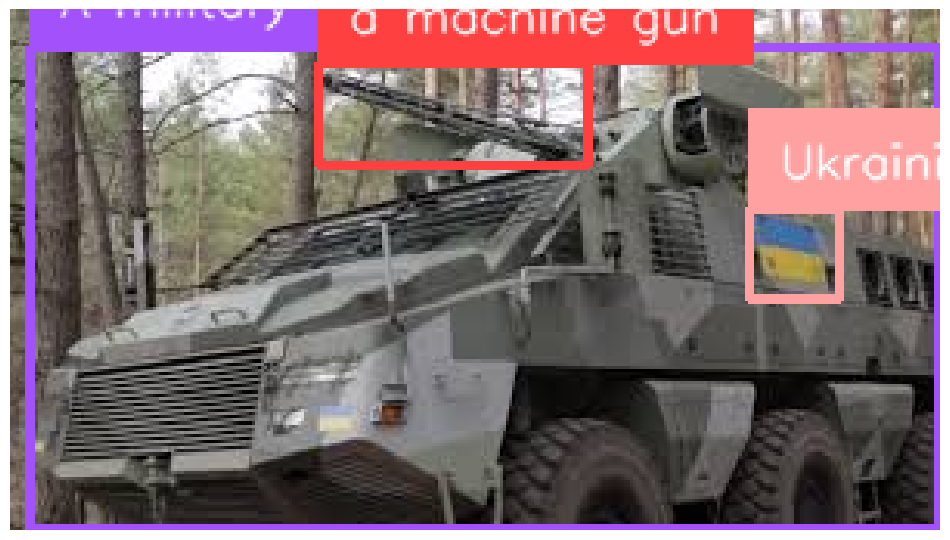

In [222]:
task_prompt ='<CAPTION_TO_PHRASE_GROUNDING>'
text_prompt="A military vehicle with a machine gun and Ukrainian flag."
prompt = task_prompt+text_prompt

image = Image.open(requests.get (url, stream=True).raw)

inputs = processor(text=prompt, images=image, return_tensors="pt"). to (device, torch_dtype)

generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024, 
    do_sample=False, 
    num_beams=3, 
    use_cache=False,
)

generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
parsed_answer = processor.post_process_generation(
    generated_text, task=task_prompt, image_size=(image.width, image.height)
)
print (parsed_answer)

bounding_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup. INDEX)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, parsed_answer, resolution_wh=image.size)
annotated = bounding_box_annotator.annotate(image, detections=detections)
annotated = label_annotator.annotate(annotated, detections=detections)
sv.plot_image(annotated)